In [1]:
import os
import multiprocessing

num_cores = multiprocessing.cpu_count()
print(f"La máquina tiene {num_cores} núcleos disponibles.")
hilos_optimos = str(min(num_cores, 64))
print(f"Configurando OpenBLAS para usar {hilos_optimos} hilos máximos...")
os.environ['OPENBLAS_NUM_THREADS'] = hilos_optimos
os.environ['MKL_NUM_THREADS'] = hilos_optimos
os.environ['OMP_NUM_THREADS'] = hilos_optimos

La máquina tiene 224 núcleos disponibles.
Configurando OpenBLAS para usar 64 hilos máximos...


In [2]:
import numpy as np
import pandas as pd
import itertools
import json
from pathlib import Path
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, recall_score,classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
import gc

In [3]:
X = pd.read_pickle("Sets_Xy/X.pkl")
y = pd.read_pickle("Sets_Xy/y.pkl")

from sklearn.model_selection import train_test_split

#Division estratificada para muestras de cada clase a nivel de cada subset

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, 
    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, 
    random_state=42)

#Encoding de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

mapeo_labels = pd.DataFrame({
    "label_original": le.classes_,
    "label_encoded": range(len(le.classes_))
})
print("Mapeo de etiquetas:\n", mapeo_labels)
class_names = le.classes_

Mapeo de etiquetas:
                label_original  label_encoded
0                      BENIGN              0
1                         Bot              1
2                        DDoS              2
3               DoS GoldenEye              3
4                    DoS Hulk              4
5            DoS Slowhttptest              5
6               DoS slowloris              6
7                 FTP-Patator              7
8                  Heartbleed              8
9                Infiltration              9
10                   PortScan             10
11                SSH-Patator             11
12    Web Attack  Brute Force             12
13  Web Attack  Sql Injection             13
14            Web Attack  XSS             14


In [4]:
import joblib

X_train_none = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_none = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

X_val = pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian.pkl")
y_val = pd.DataFrame(y_val)

X_test = pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian.pkl")
y_test = pd.DataFrame(y_test)

y_val_1d = y_val.values.ravel() if isinstance(y_val, pd.DataFrame) else y_val.ravel()
y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test.ravel()


Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 15
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
     1    1376        0.0755%
    12    1055        0.0579%
    14     456        0.0250%
     9      25        0.0014%
    13      15        0.0008%
     8       8        0.0004%


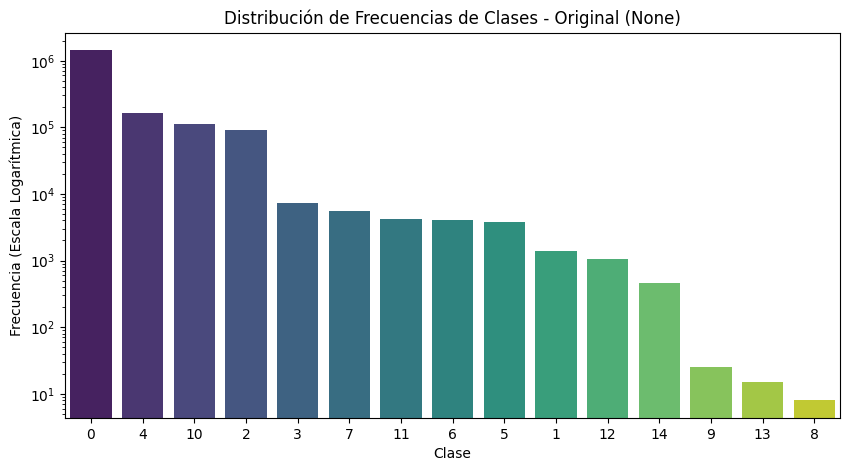

In [5]:
def analizar_distribuciones(y, nombre_dataset=""):
    total_muestras = len(y)
    classes, counts = np.unique(y, return_counts=True)
    
    sorted_idx = np.argsort(counts)[::-1]
    classes = classes[sorted_idx]
    counts = counts[sorted_idx]
    
    majority_count = counts[0]
    minority_count = counts[-1]
    imbalance_ratio = majority_count / minority_count
    
    print(f"Analisis de Distribucion: {nombre_dataset.upper()}")
    print(f"Total de muestras: {total_muestras:,}")
    print(f"Número de clases: {len(classes)}")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1\n")
    
    porcentajes = (counts / total_muestras) * 100
    df_dist = pd.DataFrame({
        'Clase': classes,
        'Conteo': counts,
        'Porcentaje (%)': porcentajes
    })
    
    df_dist['Porcentaje (%)'] = df_dist['Porcentaje (%)'].map('{:.4f}%'.format)
    
    print(df_dist.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[str(c) for c in classes], y=counts, palette="viridis", hue=[str(c) for c in classes], legend=False)
    plt.title(f"Distribución de Frecuencias de Clases - {nombre_dataset}")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia (Escala Logarítmica)")
    plt.yscale('log')
    plt.show()
    
    return classes, counts

classes, counts = analizar_distribuciones(y_train_none, "Original (None)")

In [6]:
import joblib
import numpy as np
from collections import Counter
import pandas as pd

archivos_y_train = [
    "y_train_E1_Benigno_Y_Ataques_Camuflados.joblib",
    "y_train_E2_Mayoritarios.joblib",
    "y_train_E3_DoS.joblib",
    "y_train_E4_Patator.joblib",
    "y_train_E5_Minoritarios.joblib"
]

carpeta_sets = "Sets_Expertos_MoE_2"

for archivo in archivos_y_train:
    ruta_completa = f"{carpeta_sets}/{archivo}"
    
    try:
        y_data = joblib.load(ruta_completa)
        
        if isinstance(y_data, pd.DataFrame) or isinstance(y_data, pd.Series):
            y_data = y_data.values.ravel()
            
        conteo = Counter(y_data)
        
        clases_ordenadas = conteo.most_common()
        
        print(f"Análisis de: {archivo}")
        print("Clases y sus conteos:")
        
        for clase, cantidad in clases_ordenadas:
            print(f"  Clase {int(clase)}: {cantidad:,} muestras")
        print("\n")
        
    except FileNotFoundError:
        print(f"No se encontró el archivo: {ruta_completa}. Revisa la ruta.\n")

Análisis de: y_train_E1_Benigno_Y_Ataques_Camuflados.joblib
Clases y sus conteos:
  Clase 0: 1,433,001 muestras
  Clase 4: 12,526 muestras
  Clase 10: 8,612 muestras
  Clase 2: 6,937 muestras
  Clase 1: 1,376 muestras
  Clase 12: 1,055 muestras
  Clase 3: 558 muestras
  Clase 14: 456 muestras
  Clase 7: 431 muestras
  Clase 11: 320 muestras
  Clase 6: 315 muestras
  Clase 5: 298 muestras
  Clase 13: 15 muestras
  Clase 9: 2 muestras
  Clase 8: 1 muestras


Análisis de: y_train_E2_Mayoritarios.joblib
Clases y sus conteos:
  Clase 0: 588,603 muestras
  Clase 4: 161,751 muestras
  Clase 10: 111,251 muestras
  Clase 2: 89,619 muestras
  Clase 3: 2,960 muestras
  Clase 7: 2,283 muestras
  Clase 11: 1,696 muestras
  Clase 6: 1,667 muestras
  Clase 5: 1,581 muestras
  Clase 1: 566 muestras
  Clase 12: 434 muestras
  Clase 14: 188 muestras
  Clase 9: 11 muestras
  Clase 13: 7 muestras
  Clase 8: 4 muestras


Análisis de: y_train_E3_DoS.joblib
Clases y sus conteos:
  Clase 0: 61,003 muestras
  

In [7]:
X_train_base = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_base = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

if isinstance(y_train_base, pd.DataFrame) or isinstance(y_train_base, pd.Series):
    y_train_base = y_train_base.values.ravel()

CLASE_BENIGNA = 0
clases_experto_1 = [0, 1, 12, 13, 14]
clases_experto_2 = [2, 4, 10]
clases_experto_3 = [3, 5, 6]
clases_experto_4 = [7, 11]
clases_experto_5 = [8, 9]

In [8]:
import numpy as np
import pandas as pd
import joblib
import os
from collections import Counter

os.makedirs("Sets_Expertos_MoE", exist_ok=True)

def predecir_tamano_post_smote(y_objetivo, target_large=200000):
    counts = Counter(y_objetivo)
    total_futuro = 0
    
    for cls, cnt in counts.items():
        if cls == CLASE_BENIGNA:
            total_futuro += cnt
        elif cnt < 1000: 
            total_futuro += max(cnt * 50, 30000)     
        elif cnt < 5000:
            total_futuro += max(cnt * 20, 60000)
        elif cnt < 10000:
            total_futuro += max(cnt * 15, 100000)
        else:
            total_futuro += max(cnt, target_large)
            
    return total_futuro

def estratificar_con_minimo(X_pool, y_pool, n_samples):
    counts = Counter(y_pool)
    total_pool = len(y_pool)
    unique_classes = list(counts.keys())

    if n_samples >= total_pool:
        return X_pool, y_pool

    target_counts = {cls: 1 for cls in unique_classes}
    restantes = n_samples - len(unique_classes)

    for cls in unique_classes:
        prop = counts[cls] / total_pool
        adicionales = int(np.floor(restantes * prop))
        target_counts[cls] += adicionales
        target_counts[cls] = min(target_counts[cls], counts[cls])

    actual_total = sum(target_counts.values())
    faltantes = n_samples - actual_total

    if faltantes > 0:
        clases_ordenadas = sorted(unique_classes, key=lambda c: counts[c], reverse=True)
        for cls in clases_ordenadas:
            if faltantes == 0:
                break
            espacio_disponible = counts[cls] - target_counts[cls]
            if espacio_disponible > 0:
                agregar = min(faltantes, espacio_disponible)
                target_counts[cls] += agregar
                faltantes -= agregar

    indices_muestreados = []
    rng = np.random.default_rng(42)
    
    for cls, t_count in target_counts.items():
        idx_clase = np.where(y_pool == cls)[0]
        seleccion = rng.choice(idx_clase, size=t_count, replace=False)
        indices_muestreados.extend(seleccion)

    rng.shuffle(indices_muestreados)

    if hasattr(X_pool, 'iloc'):
        X_sample = X_pool.iloc[indices_muestreados]
    else:
        X_sample = X_pool[indices_muestreados]

    y_sample = y_pool[indices_muestreados]

    return X_sample, y_sample

def generar_subset_experto_exacto(X, y, clases_objetivo, clase_benigna=0, nombre_experto="Experto"):
    mask_objetivo = np.isin(y, clases_objetivo)
    X_objetivo = X[mask_objetivo]
    y_objetivo = y[mask_objetivo]
    
    mask_ruido = ~np.isin(y, clases_objetivo)
    X_ruido_pool = X[mask_ruido]
    y_ruido_pool = y[mask_ruido]
    
    tamano_objetivo_futuro = predecir_tamano_post_smote(y_objetivo)
    
    n_ruido = tamano_objetivo_futuro
    n_ruido = min(n_ruido, len(y_ruido_pool))
    
    if n_ruido > 0:
        if n_ruido == len(y_ruido_pool):
            X_ruido_sample = X_ruido_pool
            y_ruido_sample = y_ruido_pool
        else:
            X_ruido_sample, y_ruido_sample = estratificar_con_minimo(X_ruido_pool, y_ruido_pool, n_samples=n_ruido)
        
        if hasattr(X, 'iloc'):
            X_final = pd.concat([X_objetivo, X_ruido_sample], axis=0)
        else:
            X_final = np.vstack((X_objetivo, X_ruido_sample))
        y_final = np.concatenate([y_objetivo, y_ruido_sample])
    else:
        X_final = X_objetivo
        y_final = y_objetivo

    # joblib.dump(X_final, f"Sets_Expertos_MoE/X_train_{nombre_experto}.joblib")
    # joblib.dump(y_final, f"Sets_Expertos_MoE/y_train_{nombre_experto}.joblib")
    
    print(f"{nombre_experto.upper()}")
    muestras_objetivo_actual = len(y_objetivo)
    muestras_ruido_actual = len(y_final) - muestras_objetivo_actual
    
    print(f"Estado Antes de SMOTE:")
    print(f"Objetivo: {muestras_objetivo_actual:,} | Ruido inyectado: {muestras_ruido_actual:,}")
    
    total_futuro = tamano_objetivo_futuro + n_ruido
    pct_obj = (tamano_objetivo_futuro / total_futuro) * 100
    pct_ruido = (n_ruido / total_futuro) * 100
    
    print(f"Estado Post-SMOTE Estimado:")
    print(f"Objetivo: {tamano_objetivo_futuro:,} ({pct_obj:.2f}%) | Ruido: {n_ruido:,} ({pct_ruido:.2f}%)\n")
    
    return X_final, y_final

print("Evaluando subsets de expertos con las nuevas reglas de balanceo...\n")

X_e1, y_e1 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_1, nombre_experto="E1_Benigno_Y_Ataques_Camuflados")
X_e2, y_e2 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_2, nombre_experto="E2_Mayoritarios")
X_e3, y_e3 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_3, nombre_experto="E3_DoS")
X_e4, y_e4 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_4, nombre_experto="E4_Patator")
X_e5, y_e5 = generar_subset_experto_exacto(X_train_base, y_train_base, clases_experto_5, nombre_experto="E5_Minoritarios")

Evaluando subsets de expertos con las nuevas reglas de balanceo...

E1_BENIGNO_Y_ATAQUES_CAMUFLADOS
Estado Antes de SMOTE:
Objetivo: 1,435,903 | Ruido inyectado: 387,450
Estado Post-SMOTE Estimado:
Objetivo: 1,613,001 (80.63%) | Ruido: 387,450 (19.37%)

E2_MAYORITARIOS
Estado Antes de SMOTE:
Objetivo: 362,621 | Ruido inyectado: 600,000
Estado Post-SMOTE Estimado:
Objetivo: 600,000 (50.00%) | Ruido: 600,000 (50.00%)

E3_DOS
Estado Antes de SMOTE:
Objetivo: 15,111 | Ruido inyectado: 266,195
Estado Post-SMOTE Estimado:
Objetivo: 266,195 (50.00%) | Ruido: 266,195 (50.00%)

E4_PATATOR
Estado Antes de SMOTE:
Objetivo: 9,685 | Ruido inyectado: 182,560
Estado Post-SMOTE Estimado:
Objetivo: 182,560 (50.00%) | Ruido: 182,560 (50.00%)

E5_MINORITARIOS
Estado Antes de SMOTE:
Objetivo: 33 | Ruido inyectado: 60,000
Estado Post-SMOTE Estimado:
Objetivo: 60,000 (50.00%) | Ruido: 60,000 (50.00%)



In [9]:
def get_ids_proportions(y, clases_experto, target_large=200000):
    counts = Counter(y)
    proportion_dict = {}

    for cls in clases_experto:
        cnt = counts.get(cls, 0)
        if cnt == 0: continue
            
        if cls == 0: 
            continue
        elif cnt < 1000:
            proportion_dict[cls] = max(cnt * 50, 30000)
        elif cnt < 5000:
            proportion_dict[cls] = max(cnt * 20, 60000)
        elif cnt < 10000:
            proportion_dict[cls] = max(cnt * 15, 100000)
        else:
            proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [10]:
import joblib

proportion_dict_E1 = get_ids_proportions(y_train_base, clases_experto_1)
proportion_dict_E2 = get_ids_proportions(y_train_base, clases_experto_2)
proportion_dict_E3 = get_ids_proportions(y_train_base, clases_experto_3)
proportion_dict_E4 = get_ids_proportions(y_train_base, clases_experto_4)
proportion_dict_E5 = get_ids_proportions(y_train_base, clases_experto_5)

print("Diccionarios por sets para los expertos")
print(f"E1: {proportion_dict_E1}")
print(f"E2: {proportion_dict_E2}")
print(f"E3: {proportion_dict_E3}")
print(f"E4: {proportion_dict_E4}")
print(f"E5: {proportion_dict_E5}")

Diccionarios por sets para los expertos
E1: {1: 60000, 12: 60000, 13: 30000, 14: 30000}
E2: {2: 200000, 4: 200000, 10: 200000}
E3: {3: 108075, 5: 76980, 6: 81140}
E4: {7: 100000, 11: 82560}
E5: {8: 30000, 9: 30000}


In [11]:
class OversamplingWithArtifactAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, method='smote', proportion=None, random_state=42, n_neighbors=5, **kwargs):
        self.method = method
        self.proportion = proportion
        self.random_state = random_state
        self.n_neighbors = n_neighbors
        self.kwargs = kwargs
        
        self.oversampler_ = None
        self.artifacts_report_ = {}

    def fit(self, X, y=None):
        if self.method == 'none':
            return self

        if self.method == 'smote':
            self.oversampler_ = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
        elif self.method == 'smote_tomek':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTETomek(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        elif self.method == 'smote_enn':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTEENN(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        
        return self

    def fit_resample(self, X, y):
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
        orig_counts = Counter(y)

        if self.method == 'none':
            self._generar_reporte_avanzado(X, y, X, y, orig_counts, orig_counts)
            return X, y

        self.fit(X, y)
        
        X_res, y_res = self.oversampler_.fit_resample(X, y)
        new_counts = Counter(y_res)
        
        self._generar_reporte_avanzado(X, y, X_res, y_res, orig_counts, new_counts)

        if feature_names:
            X_res = pd.DataFrame(X_res, columns=feature_names)
            
        return X_res, y_res

    def _generar_reporte_avanzado(self, X_orig, y_orig, X_res, y_res, orig_counts, new_counts):
        if hasattr(X_orig, 'values'): X_orig = X_orig.values
        if hasattr(y_orig, 'values'): y_orig = y_orig.values
        if hasattr(X_res, 'values'): X_res = X_res.values
        if hasattr(y_res, 'values'): y_res = y_res.values

        reporte = {
            'metodo': self.method,
            'proporcion_config': {str(k): int(v) for k, v in self.proportion.items()} if isinstance(self.proportion, dict) else self.proportion,
            'resumen': {
                'muestras_antes': int(sum(orig_counts.values())),
                'muestras_despues': int(sum(new_counts.values())),
                'incremento_total': int(sum(new_counts.values()) - sum(orig_counts.values()))
            },
            'distribucion_original': {str(k): int(v) for k, v in orig_counts.items()},
            'distribucion_final': {str(k): int(v) for k, v in new_counts.items()},
            'analisis_por_clase': {}
        }

        unique_classes = np.unique(y_orig)
        print(f"\nCalculando métricas de artefactos para: {self.method.upper()}...")

        n_orig_total = len(X_orig)
        if self.method == 'smote':
            X_synth_global = X_res[n_orig_total:]
            y_synth_global = y_res[n_orig_total:]

        for clase in unique_classes:
            clase_str = str(clase)
            c_orig = orig_counts.get(clase, 0)
            c_new = new_counts.get(clase, 0)

            X_orig_c = X_orig[y_orig == clase]
            
            if self.method == 'smote':
                X_synth_c = X_synth_global[y_synth_global == clase]
            else:
                X_res_c = X_res[y_res == clase]
                if len(X_orig_c) > 0 and len(X_res_c) > 0:
                    nn_filter = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(X_orig_c)
                    dists, _ = nn_filter.kneighbors(X_res_c)
                    X_synth_c = X_res_c[dists.flatten() > 1e-6]
                else:
                    X_synth_c = np.array([])

            if c_new > c_orig: estado = "Oversampled"
            elif c_new < c_orig: estado = "Undersampled / Limpiado"
            else: estado = "Intacto"

            clase_info = {
                "estado": estado,
                "originales": int(c_orig),
                "finales": int(c_new),
                "sinteticas_puras_detectadas": int(len(X_synth_c)),
                "multiplicador": float(round(c_new / c_orig, 2)) if c_orig > 0 else 0.0
            }

            if len(X_orig_c) > 1 and len(X_synth_c) > 0 and estado != "Intacto":
                
                #Distancia interna original
                nn_baseline = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1)
                nn_baseline.fit(X_orig_c)
                dist_base, _ = nn_baseline.kneighbors(X_orig_c)
                mean_dist_base = float(np.mean(dist_base[:, 1]))

                #Distancia total de los datos nuevos hacia los originales
                nn_post = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
                nn_post.fit(X_orig_c)
                dist_post, _ = nn_post.kneighbors(X_synth_c)
                mean_dist_post = float(np.mean(dist_post))
                
                #Detectar duplicados exactos
                duplicados_pct = float(np.sum(dist_post < 1e-8) / len(dist_post) * 100)

                #Evaluación de Riesgo de Artefactos
                riesgo = "Bajo (Consistente)"
                if duplicados_pct > 5.0:
                    riesgo = f"Alto (Alerta de Duplicidad: {round(duplicados_pct, 1)}%)"
                elif mean_dist_base > 0 and (mean_dist_post > mean_dist_base * 2.5):
                    riesgo = "Alto (Artefactos Lejanos / Ruido)"

                clase_info["metricas_vecindario"] = {
                    "distancia_media_interna_original": float(round(mean_dist_base, 6)),
                    "distancia_media_sinteticos_a_originales": float(round(mean_dist_post, 6)),
                    "porcentaje_duplicados_exactos": float(round(duplicados_pct, 2)),
                    "riesgo_artefactos": riesgo
                }

            reporte['analisis_por_clase'][clase_str] = clase_info

        self.artifacts_report_ = reporte
        
        print(f"Análisis completado. Muestras: {reporte['resumen']['muestras_antes']} -> {reporte['resumen']['muestras_despues']}")
        
        for k, v in reporte['analisis_por_clase'].items():
            if 'metricas_vecindario' in v and "Alto" in v['metricas_vecindario']['riesgo_artefactos']:
                print(f"Precaución Clase {k}: {v['metricas_vecindario']['riesgo_artefactos']}")

    def transform(self, X):
        return X

    def get_artifacts_report(self):
        return self.artifacts_report_

    def save_report(self, filepath):
        with open(filepath, 'w') as f:
            json.dump(self.artifacts_report_, f, indent=2, default=str)

Analisis de Distribucion: SET-E1-PREVIO SMOTE
Total de muestras: 1,465,903
Número de clases: 15
Imbalance Ratio: 1433001.00:1

 Clase  Conteo Porcentaje (%)
   0.0 1433001       97.7555%
   4.0   12526        0.8545%
  10.0    8612        0.5875%
   2.0    6937        0.4732%
   1.0    1376        0.0939%
  12.0    1055        0.0720%
   3.0     558        0.0381%
  14.0     456        0.0311%
   7.0     431        0.0294%
  11.0     320        0.0218%
   6.0     315        0.0215%
   5.0     298        0.0203%
  13.0      15        0.0010%
   9.0       2        0.0001%
   8.0       1        0.0001%


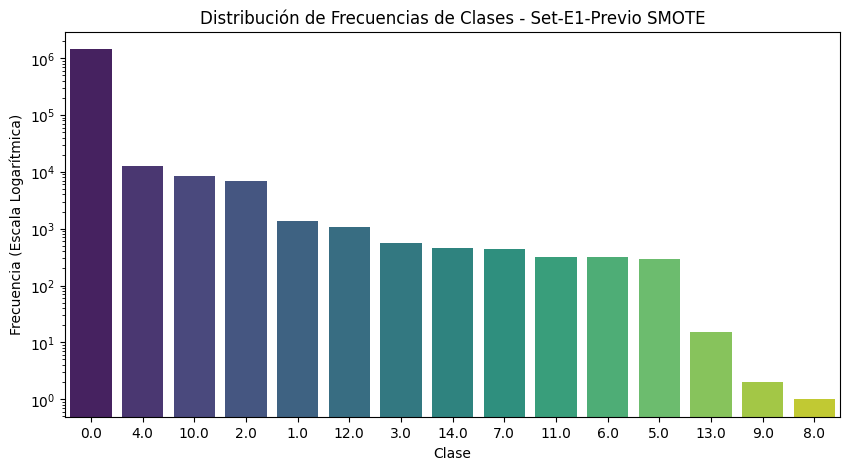

Analisis de Distribucion: SET-E2-PREVIO SMOTE
Total de muestras: 962,621
Número de clases: 15
Imbalance Ratio: 147150.75:1

 Clase  Conteo Porcentaje (%)
   0.0  588603       61.1459%
   4.0  161751       16.8032%
  10.0  111251       11.5571%
   2.0   89619        9.3099%
   3.0    2960        0.3075%
   7.0    2283        0.2372%
  11.0    1696        0.1762%
   6.0    1667        0.1732%
   5.0    1581        0.1642%
   1.0     566        0.0588%
  12.0     434        0.0451%
  14.0     188        0.0195%
   9.0      11        0.0011%
  13.0       7        0.0007%
   8.0       4        0.0004%


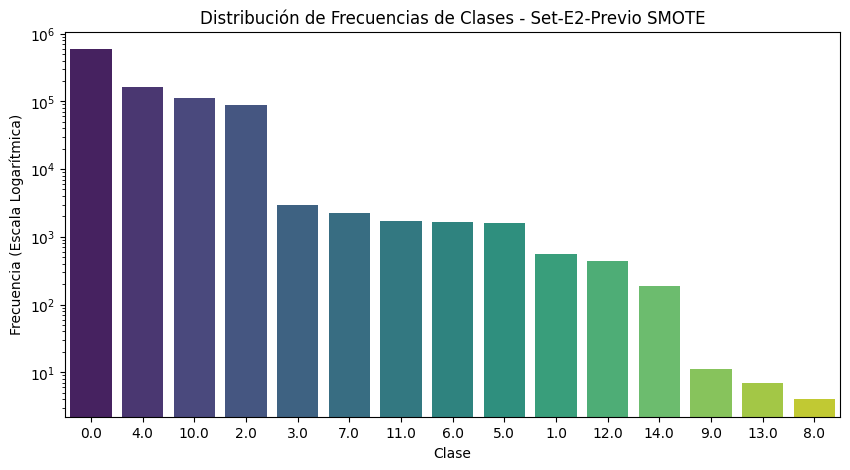

Analisis de Distribucion: SET-E3-PREVIO SMOTE
Total de muestras: 92,091
Número de clases: 15
Imbalance Ratio: 61003.00:1

 Clase  Conteo Porcentaje (%)
   0.0   61003       66.2421%
   3.0    7205        7.8238%
   4.0    6885        7.4763%
  10.0    4736        5.1427%
   6.0    4057        4.4054%
   5.0    3849        4.1796%
   2.0    3815        4.1426%
   7.0     237        0.2574%
  11.0     176        0.1911%
   1.0      59        0.0641%
  12.0      45        0.0489%
  14.0      20        0.0217%
   9.0       2        0.0022%
   8.0       1        0.0011%
  13.0       1        0.0011%


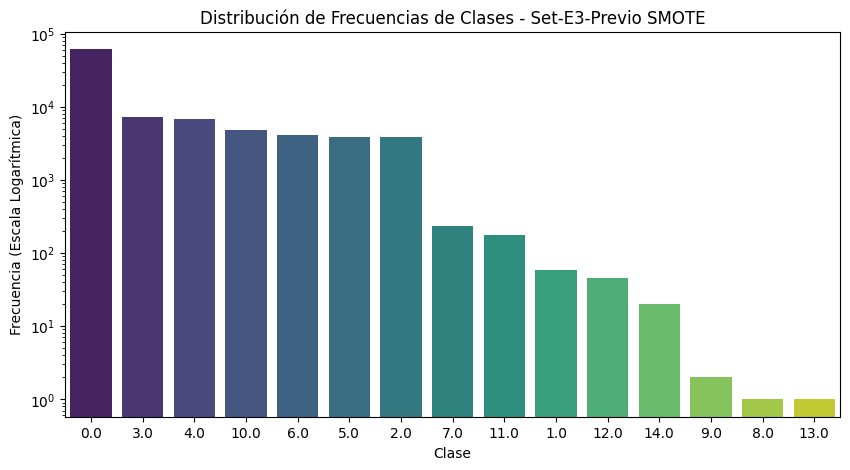

Analisis de Distribucion: SET-E4-PREVIO SMOTE
Total de muestras: 192,245
Número de clases: 15
Imbalance Ratio: 144239.00:1

 Clase  Conteo Porcentaje (%)
   0.0  144239       75.0287%
   4.0   16281        8.4689%
  10.0   11198        5.8249%
   2.0    9021        4.6924%
   7.0    5557        2.8906%
  11.0    4128        2.1473%
   3.0     726        0.3776%
   6.0     409        0.2127%
   5.0     388        0.2018%
   1.0     139        0.0723%
  12.0     107        0.0557%
  14.0      46        0.0239%
   9.0       3        0.0016%
  13.0       2        0.0010%
   8.0       1        0.0005%


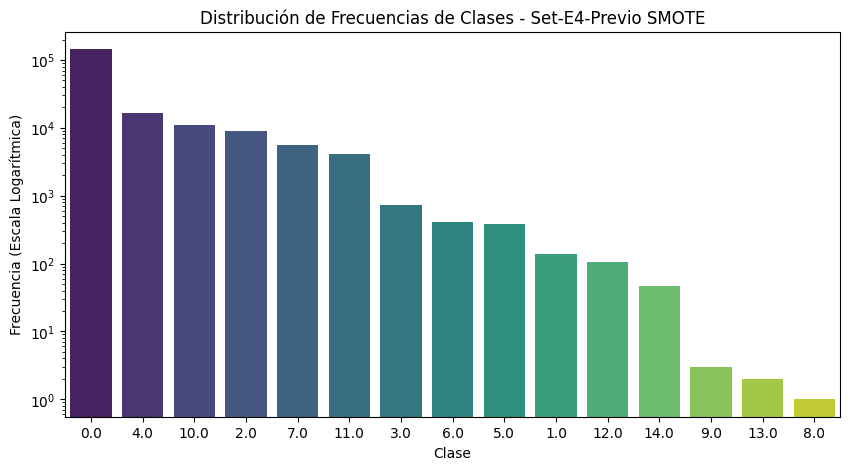

Analisis de Distribucion: SET-E5-PREVIO SMOTE
Total de muestras: 30,033
Número de clases: 15
Imbalance Ratio: 23575.00:1

 Clase  Conteo Porcentaje (%)
   0.0   23575       78.4970%
   4.0    2661        8.8603%
  10.0    1830        6.0933%
   2.0    1474        4.9079%
   3.0     119        0.3962%
   7.0      92        0.3063%
  11.0      68        0.2264%
   6.0      67        0.2231%
   5.0      64        0.2131%
   9.0      25        0.0832%
   1.0      23        0.0766%
  12.0      18        0.0599%
  14.0       8        0.0266%
   8.0       8        0.0266%
  13.0       1        0.0033%


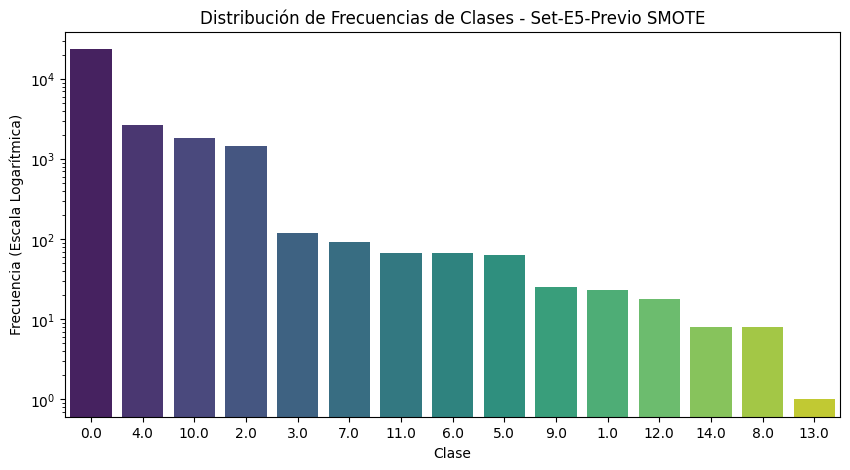

In [12]:
import joblib
import numpy as np

carpeta_sets = "Sets_Expertos_MoE_2"

X_train_E1 = joblib.load(f"{carpeta_sets}/X_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)
y_train_E1 = joblib.load(f"{carpeta_sets}/y_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)

X_train_E2 = joblib.load(f"{carpeta_sets}/X_train_E2_Mayoritarios.joblib").astype(np.float32)
y_train_E2 = joblib.load(f"{carpeta_sets}/y_train_E2_Mayoritarios.joblib").astype(np.float32)

X_train_E3 = joblib.load(f"{carpeta_sets}/X_train_E3_DoS.joblib").astype(np.float32)
y_train_E3 = joblib.load(f"{carpeta_sets}/y_train_E3_DoS.joblib").astype(np.float32)

X_train_E4 = joblib.load(f"{carpeta_sets}/X_train_E4_Patator.joblib").astype(np.float32)
y_train_E4 = joblib.load(f"{carpeta_sets}/y_train_E4_Patator.joblib").astype(np.float32)

X_train_E5 = joblib.load(f"{carpeta_sets}/X_train_E5_Minoritarios.joblib").astype(np.float32)
y_train_E5 = joblib.load(f"{carpeta_sets}/y_train_E5_Minoritarios.joblib").astype(np.float32)

classes, counts = analizar_distribuciones(y_train_E1, "Set-E1-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E2, "Set-E2-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E3, "Set-E3-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E4, "Set-E4-Previo SMOTE")
classes, counts = analizar_distribuciones(y_train_E5, "Set-E5-Previo SMOTE")

Analisis de Distribucion: SET-E1-PREVIO SMOTE
Total de muestras: 1,465,903
Número de clases: 15
Imbalance Ratio: 1433001.00:1

 Clase  Conteo Porcentaje (%)
   0.0 1433001       97.7555%
   4.0   12526        0.8545%
  10.0    8612        0.5875%
   2.0    6937        0.4732%
   1.0    1376        0.0939%
  12.0    1055        0.0720%
   3.0     558        0.0381%
  14.0     456        0.0311%
   7.0     431        0.0294%
  11.0     320        0.0218%
   6.0     315        0.0215%
   5.0     298        0.0203%
  13.0      15        0.0010%
   9.0       2        0.0001%
   8.0       1        0.0001%


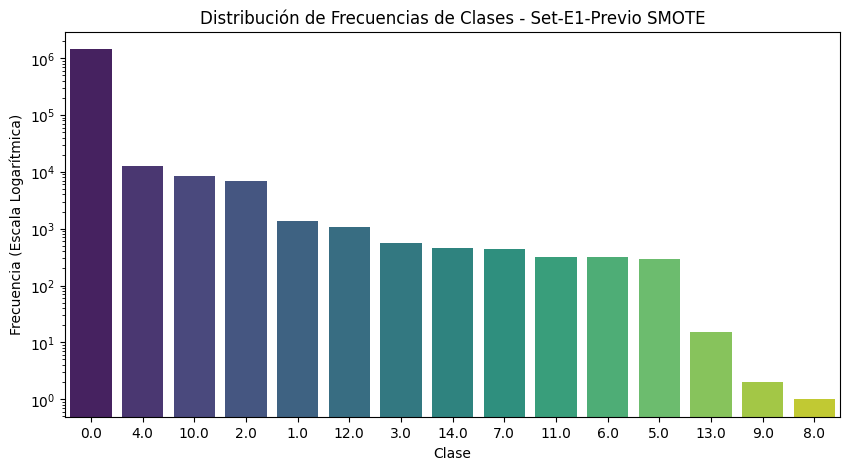

Analisis de Distribucion: SET-E2-PREVIO SMOTE
Total de muestras: 962,621
Número de clases: 15
Imbalance Ratio: 147150.75:1

 Clase  Conteo Porcentaje (%)
   0.0  588603       61.1459%
   4.0  161751       16.8032%
  10.0  111251       11.5571%
   2.0   89619        9.3099%
   3.0    2960        0.3075%
   7.0    2283        0.2372%
  11.0    1696        0.1762%
   6.0    1667        0.1732%
   5.0    1581        0.1642%
   1.0     566        0.0588%
  12.0     434        0.0451%
  14.0     188        0.0195%
   9.0      11        0.0011%
  13.0       7        0.0007%
   8.0       4        0.0004%


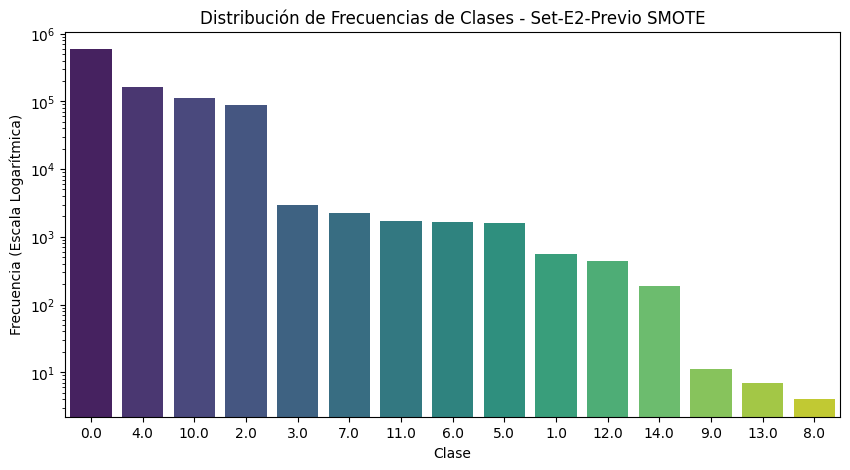

Analisis de Distribucion: SET-E3-PREVIO SMOTE
Total de muestras: 92,091
Número de clases: 15
Imbalance Ratio: 61003.00:1

 Clase  Conteo Porcentaje (%)
   0.0   61003       66.2421%
   3.0    7205        7.8238%
   4.0    6885        7.4763%
  10.0    4736        5.1427%
   6.0    4057        4.4054%
   5.0    3849        4.1796%
   2.0    3815        4.1426%
   7.0     237        0.2574%
  11.0     176        0.1911%
   1.0      59        0.0641%
  12.0      45        0.0489%
  14.0      20        0.0217%
   9.0       2        0.0022%
   8.0       1        0.0011%
  13.0       1        0.0011%


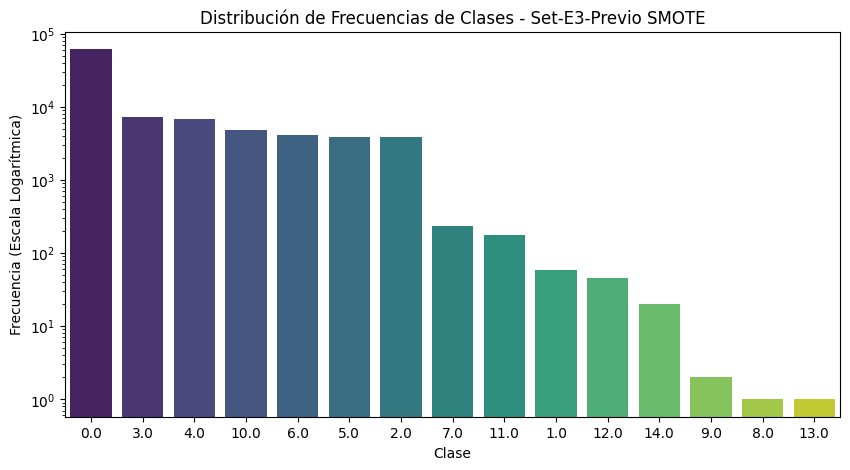

Analisis de Distribucion: SET-E4-PREVIO SMOTE
Total de muestras: 192,245
Número de clases: 15
Imbalance Ratio: 144239.00:1

 Clase  Conteo Porcentaje (%)
   0.0  144239       75.0287%
   4.0   16281        8.4689%
  10.0   11198        5.8249%
   2.0    9021        4.6924%
   7.0    5557        2.8906%
  11.0    4128        2.1473%
   3.0     726        0.3776%
   6.0     409        0.2127%
   5.0     388        0.2018%
   1.0     139        0.0723%
  12.0     107        0.0557%
  14.0      46        0.0239%
   9.0       3        0.0016%
  13.0       2        0.0010%
   8.0       1        0.0005%


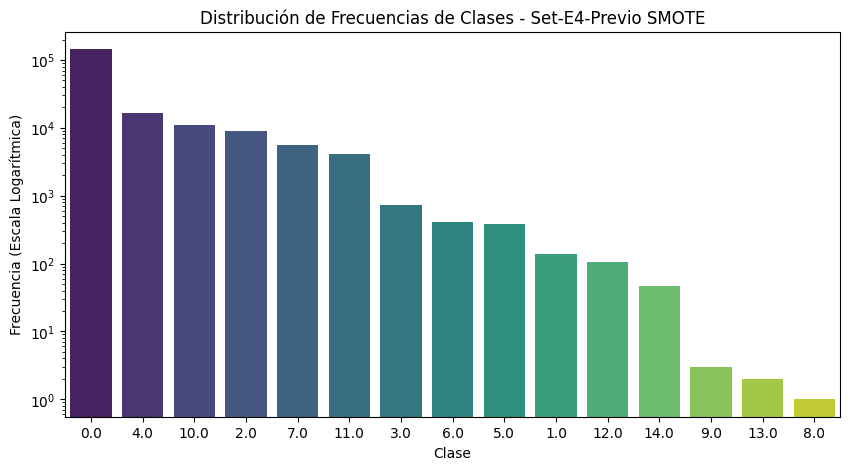

Analisis de Distribucion: SET-E5-PREVIO SMOTE
Total de muestras: 30,033
Número de clases: 15
Imbalance Ratio: 23575.00:1

 Clase  Conteo Porcentaje (%)
   0.0   23575       78.4970%
   4.0    2661        8.8603%
  10.0    1830        6.0933%
   2.0    1474        4.9079%
   3.0     119        0.3962%
   7.0      92        0.3063%
  11.0      68        0.2264%
   6.0      67        0.2231%
   5.0      64        0.2131%
   9.0      25        0.0832%
   1.0      23        0.0766%
  12.0      18        0.0599%
  14.0       8        0.0266%
   8.0       8        0.0266%
  13.0       1        0.0033%


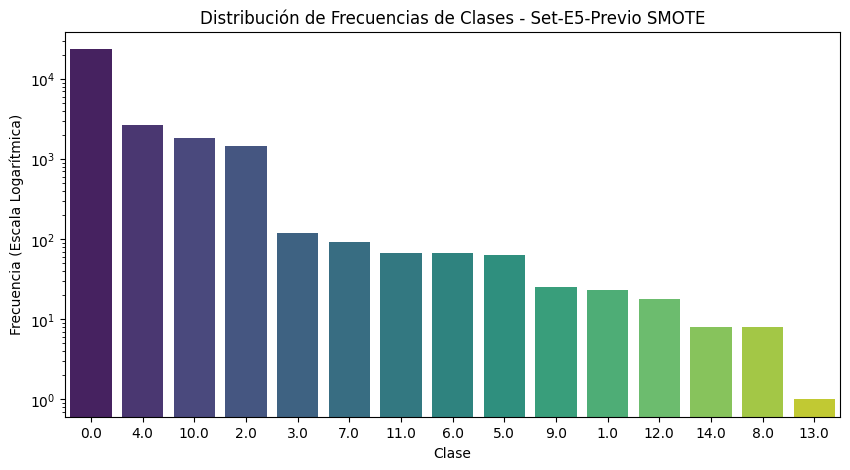

In [13]:
import joblib
import numpy as np

carpeta_sets = "Sets_Expertos_MoE_2"

X_train_E1 = joblib.load(f"{carpeta_sets}/X_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)
y_train_E1 = joblib.load(f"{carpeta_sets}/y_train_E1_Benigno_Y_Ataques_Camuflados.joblib").astype(np.float32)

X_train_E2 = joblib.load(f"{carpeta_sets}/X_train_E2_Mayoritarios.joblib").astype(np.float32)
y_train_E2 = joblib.load(f"{carpeta_sets}/y_train_E2_Mayoritarios.joblib").astype(np.float32)

X_train_E3 = joblib.load(f"{carpeta_sets}/X_train_E3_DoS.joblib").astype(np.float32)
y_train_E3 = joblib.load(f"{carpeta_sets}/y_train_E3_DoS.joblib").astype(np.float32)

X_train_E4 = joblib.load(f"{carpeta_sets}/X_train_E4_Patator.joblib").astype(np.float32)
y_train_E4 = joblib.load(f"{carpeta_sets}/y_train_E4_Patator.joblib").astype(np.float32)

X_train_E5 = joblib.load(f"{carpeta_sets}/X_train_E5_Minoritarios.joblib").astype(np.float32)
y_train_E5 = joblib.load(f"{carpeta_sets}/y_train_E5_Minoritarios.joblib").astype(np.float32)

for i, y in enumerate([y_train_E1, y_train_E2, y_train_E3, y_train_E4, y_train_E5]):
    analizar_distribuciones(y, f"Set-E{i+1}-Previo SMOTE")

In [14]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os
from functools import partial

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TensorDataLoader:
    
    def __init__(self, X, y, batch_size, shuffle=False):
        self.X = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.long).to(device)
        self.dataset_len = self.X.shape[0]
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        if self.shuffle:
            self.indices = torch.randperm(self.dataset_len, device=device)
        else:
            self.indices = None
        self.i = 0
        return self

    def __next__(self):
        if self.i >= self.dataset_len:
            raise StopIteration
        
        if self.indices is not None:
            idx = self.indices[self.i : self.i + self.batch_size]
            batch_X = self.X[idx]
            batch_y = self.y[idx]
        else:
            batch_X = self.X[self.i : self.i + self.batch_size]
            batch_y = self.y[self.i : self.i + self.batch_size]
            
        self.i += self.batch_size
        return batch_X, batch_y

    def __len__(self):
        return (self.dataset_len + self.batch_size - 1)

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate, activation_name, num_classes=15):
        super().__init__()
        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU(),
            'relu': nn.ReLU()
        }
        activation_layer = activations[activation_name]
        
        layers = []
        in_f = input_dim
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
            
        layers.append(nn.Linear(in_f, num_classes))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): 
        return self.net(x)
    
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-ce_loss)
        
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [15]:
import os
import copy
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score
from datetime import datetime

def objective(trial, X_train, y_train, X_val, y_val, input_dim, nombre_experto, clases_objetivo):
    batch_size = trial.suggest_categorical('batch_size', [4096, 8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    epochs = trial.suggest_int('epochs', 50, 100)
    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0)
    
    n_layers = trial.suggest_int('n_layers', 2, 4)
    shape_strategy = trial.suggest_categorical('mlp_shape', ['bottleneck', 'flat'])
    
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 256, 1024, step=256)
    hidden_layers.append(base_units)
    
    if shape_strategy == 'flat':
        for _ in range(1, n_layers):
            hidden_layers.append(base_units)
    else:
        prev_units = base_units
        for i in range(1, n_layers):
            units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
            hidden_layers.append(units)
            prev_units = units

    os.makedirs("Modelos_Expertos_2", exist_ok=True)
    log_file_path = f"Modelos_Expertos_2/Registro_Logs_{nombre_experto}.txt"

    with open(log_file_path, "a") as log_file:
        log_file.write(f"\n[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Iniciando Trial {trial.number}\n")
        log_file.write(f"Parametros Optuna: {trial.params}\n")

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    model = TabularMLP(input_dim=input_dim, hidden_layers=hidden_layers, dropout_rate=dropout_rate, activation_name=activation_name).to(device)
    
    criterion = FocalLoss(gamma=focal_gamma)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
    scaler = torch.amp.GradScaler(device_type)

    best_macro_f1 = 0.0
    patience_counter = 0
    early_stopping_patience = 10
    best_model_state = None 
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type=device_type):
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        model.eval()
        val_loss = 0.0
        y_true_list = []
        y_pred_list = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast(device_type=device_type):
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    
                val_loss += loss.item() * batch_X.size(0)
                _, preds = torch.max(outputs, 1)
                
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        val_loss = val_loss / len(val_loader)
        scheduler.step(val_loss)
        
        current_macro_f1 = f1_score(y_true_all, y_pred_all, labels=clases_objetivo, average='macro', zero_division=0)
    
        trial.report(current_macro_f1, epoch)
        if trial.should_prune():
            with open(log_file_path, "a") as log_file:
                log_file.write(f"Trial {trial.number} podado en epoca {epoch}. F1: {current_macro_f1:.4f}\n")
            raise optuna.TrialPruned()
            
        if current_macro_f1 > best_macro_f1:
            best_macro_f1 = current_macro_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
            
            with open(log_file_path, "a") as log_file:
                log_file.write(f"Trial {trial.number} | Epoca {epoch} | Nuevo Mejor F1: {best_macro_f1:.4f} | Val Loss: {val_loss:.4f}\n")
        else:
            patience_counter += 1
            
        if patience_counter >= early_stopping_patience:
            with open(log_file_path, "a") as log_file:
                log_file.write(f"Trial {trial.number} | Early stopping en epoca {epoch}.\n")
            break

    if best_model_state is not None:
        ruta_guardado = f"Modelos_Expertos_2/{nombre_experto}_trial_{trial.number}.pth"
        torch.save(best_model_state, ruta_guardado)
        
        with open(log_file_path, "a") as log_file:
            log_file.write(f"Fin Trial {trial.number} | Mejor F1 Final: {best_macro_f1:.4f}\n")
            log_file.write(f"Parametros\n")
            log_file.write(f"input_dim: {input_dim}\n")
            log_file.write(f"hidden_layers: {hidden_layers}\n")
            log_file.write(f"dropout_rate: {dropout_rate}\n")
            log_file.write(f"activation_name: '{activation_name}'\n")
            log_file.write(f"Ruta de pesos: {ruta_guardado}\n")

    return best_macro_f1

In [16]:
clases_por_experto = {
    1: [0, 1, 12, 13, 14],
    2: [2, 4, 10],
    3: [3, 5, 6],
    4: [7, 11],
    5: [8, 9]
}

tipos_oversampling = ['none', 'smote', 'smote_tomek', 'smote_enn']

In [ ]:
import optuna
import joblib
import gc
import numpy as np
from functools import partial

for tipo in tipos_oversampling:
    
    for i in range(1, 6):
        print(f"\nIniciando Entrenamiento Experto {i} con {tipo}")  
        X_train_input = joblib.load(f"Sets_Oversampling_MoE/X_train_{tipo}_Experto_{i}.joblib").astype(np.float32)
        y_train_input = joblib.load(f"Sets_Oversampling_MoE/y_train_{tipo}_Experto_{i}.joblib").astype(np.float32)
        input_dimension = X_train_input.shape[1]
        nombre_exp = f"Experto_{i}_{tipo}"

        obj_func = partial(
            objective, 
            X_train=X_train_input, 
            y_train=y_train_input, 
            X_val=X_val, 
            y_val=y_val_1d, 
            input_dim=input_dimension,
            nombre_experto=nombre_exp,
            clases_objetivo=clases_por_experto[i] 
        )

        study_expert = optuna.create_study(direction="maximize", study_name=nombre_exp)
        study_expert.optimize(obj_func, n_trials=100)

        print(f"Resultados Entrenamiento Experto {i} ({tipo})")
        print(f"Mejor F1 Macro: {study_expert.best_value:.4f}")
        print(f"Mejores Hiperparámetros:\n{study_expert.best_params}")
        print(f"Mejor Trial: {study_expert.best_trial.number}")
        del X_train_input, y_train_input, obj_func
        gc.collect()

print(f"\nEntrenamiento Optuna de todos los expertos finalizado con éxito.")

In [21]:
import optuna
import copy
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from functools import partial

class DynamicGatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts, hidden_layers, dropout_rate, activation_name):
        super(DynamicGatingNetwork, self).__init__()
        activations = {
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU()
        }
        activation_layer = activations.get(activation_name, nn.LeakyReLU(0.01))
        
        layers = []
        in_f = input_dim
        for out_f in hidden_layers:
            layers.append(nn.Linear(in_f, out_f))
            layers.append(nn.BatchNorm1d(out_f))
            layers.append(activation_layer)
            layers.append(nn.Dropout(dropout_rate))
            in_f = out_f
            
        layers.append(nn.Linear(in_f, num_experts))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=1)

In [22]:
print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE...")

input_dim_total = X_train_base.shape[1]

exp_1 = TabularMLP(input_dim_total, hidden_layers=[768, 512, 384], dropout_rate=0.1883146121098866, activation_name='leaky_relu').to(device)
exp_2 = TabularMLP(input_dim_total, hidden_layers=[1024, 832, 384], dropout_rate=0.19675886320072333, activation_name='leaky_relu').to(device)
exp_3 = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768, 768], dropout_rate=0.17856112653334016, activation_name='leaky_relu').to(device)
exp_4 = TabularMLP(input_dim_total, hidden_layers=[768, 576, 384], dropout_rate=0.10924616890806127, activation_name='leaky_relu').to(device)
exp_5 = TabularMLP(input_dim_total, hidden_layers=[256, 128, 128, 64], dropout_rate=0.23539362939562208, activation_name='gelu').to(device)

print("Cargando pesos de los expertos...")

exp_1.load_state_dict(torch.load("Modelos_Expertos_2/Experto_1_smote_trial_22.pth")) 
exp_2.load_state_dict(torch.load("Modelos_Expertos_2/Experto_2_smote_trial_94.pth"))
exp_3.load_state_dict(torch.load("Modelos_Expertos_2/Experto_3_smote_trial_31.pth"))
exp_4.load_state_dict(torch.load("Modelos_Expertos_2/Experto_4_smote_trial_70.pth"))
exp_5.load_state_dict(torch.load("Modelos_Expertos_2/Experto_5_smote_trial_85.pth"))

print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5]

Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


In [23]:
def save_confusion_matrix(y_true, y_pred, name, phase="Val"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Mixture of Experts - ({phase})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'Logs_MoE_Initial_Arquitecture/{name}.png')
    plt.close()

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score
import optuna
import copy
import os

class OptunaTabularMoESoftRouting(nn.Module):
    def __init__(self, lista_expertos, gating_network):
        super(OptunaTabularMoESoftRouting, self).__init__()
        self.experts = nn.ModuleList(lista_expertos)
        self.num_experts = len(self.experts)
        self.gating = gating_network
        
        for expert in self.experts:
            for param in expert.parameters():
                param.requires_grad = True

    def forward(self, x):
        gating_logits = self.gating(x) 
        
        pesos_gating = torch.softmax(gating_logits, dim=1)

        salidas_expertos = [expert(x) for expert in self.experts] 
        salidas_apiladas = torch.stack(salidas_expertos, dim=1)
        
        pesos_gating = pesos_gating.unsqueeze(2)
        salidas_ponderadas = salidas_apiladas * pesos_gating
        
        salida_final = torch.sum(salidas_ponderadas, dim=1)
        return salida_final

In [26]:
import os
import copy
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import optuna
from functools import partial
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

def objective_gating_soft_finetune(trial, X_train, y_train, X_val, y_val, input_dim, lista_expertos, oversampling):
    batch_size = trial.suggest_categorical('batch_size', [8192, 16384])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
    activation_name = trial.suggest_categorical('activation', ['leaky_relu', 'gelu'])
    
    lr = trial.suggest_float('lr', 1e-5, 5e-4, log=True) 
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layers = []
    base_units = trial.suggest_int('n_units_l0', 64, 512, step=64)
    hidden_layers.append(base_units)
    
    prev_units = base_units
    for i in range(1, n_layers):
        units = trial.suggest_int(f'n_units_l{i}', 64, prev_units, step=64)
        hidden_layers.append(units)
        prev_units = units

    train_loader = TensorDataLoader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = TensorDataLoader(X_val, y_val, batch_size=batch_size*2, shuffle=False)

    gating_net = DynamicGatingNetwork(input_dim, len(lista_expertos), hidden_layers, dropout_rate, activation_name)
    
    moe_model = OptunaTabularMoESoftRouting(lista_expertos, gating_net).to(device)

    focal_gamma = trial.suggest_float('focal_gamma', 0.0, 5.0) 
    criterion = FocalLoss(gamma=focal_gamma) 
    
    optimizer = optim.AdamW([
        {'params': moe_model.gating.parameters(), 'lr': lr * 10},
        {'params': moe_model.experts.parameters(), 'lr': lr}
    ], weight_decay=weight_decay)

    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.amp.GradScaler('cuda')

    epochs = 50
    best_macro_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 6
    best_model_state = None 

    for epoch in range(epochs):
        moe_model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = moe_model(batch_X)
                loss = criterion(outputs, batch_y)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
        moe_model.eval()
        y_true_list, y_pred_list = [], []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast('cuda'):
                    outputs = moe_model(batch_X)
                _, preds = torch.max(outputs, 1)
                y_true_list.append(batch_y)
                y_pred_list.append(preds)
                
        y_true_all = torch.cat(y_true_list).cpu().numpy()
        y_pred_all = torch.cat(y_pred_list).cpu().numpy()
                
        current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        scheduler.step(current_f1)

        trial.report(current_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        if current_f1 > best_macro_f1:
            best_macro_f1 = current_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(moe_model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= early_stop_patience:
            break

    if best_model_state is not None:
        os.makedirs("Modelos_Gating_2", exist_ok=True)
        
        ruta_modelo = f"Modelos_Gating_2/Gating_Soft_FT_trial_{trial.number}_{oversampling}.pth"
        torch.save(best_model_state, ruta_modelo)
        
        moe_model.load_state_dict(best_model_state)
        moe_model.eval()
        
        y_true_final_list, y_pred_final_list = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                with torch.amp.autocast('cuda'):
                    outputs = moe_model(batch_X)
                _, preds = torch.max(outputs, 1)
                y_true_final_list.append(batch_y)
                y_pred_final_list.append(preds)
                
        y_true_final = torch.cat(y_true_final_list).cpu().numpy()
        y_pred_final = torch.cat(y_pred_final_list).cpu().numpy()
        
        nombres_clases = [str(c) for c in class_names] if 'class_names' in globals() else None
        reporte = classification_report(y_true_final, y_pred_final, target_names=nombres_clases, digits=4)
        matriz_conf = confusion_matrix(y_true_final, y_pred_final)
        
        ruta_log = f"Modelos_Gating_2/Gating_Soft_FT_trial_{trial.number}_{oversampling}.log"
        with open(ruta_log, 'w') as f:
            f.write(f"resultados trial {trial.number} {oversampling}\n")
            f.write("hiperparametros:\n")
            for param_name, param_value in trial.params.items():
                f.write(f"{param_name}: {param_value}\n")
            f.write(f"mejor f1 macro: {best_macro_f1:.4f}\n")
            f.write("matriz de confusion:\n")
            f.write(np.array2string(matriz_conf, separator=', '))
            f.write("\nreporte de clasificacion:\n")
            f.write(reporte)

    return best_macro_f1

In [27]:
obj_func_gating_soft = partial(
    objective_gating_soft_finetune, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos,
    oversampling="smote"
)

study_gating_soft = optuna.create_study(direction="maximize", study_name="Gating_Optimization_Soft_Finetune")
study_gating_soft.optimize(obj_func_gating_soft, n_trials=100, gc_after_trial=True)

[I 2026-04-25 16:34:06,478] A new study created in memory with name: Gating_Optimization_Soft_Finetune
[I 2026-04-25 16:34:45,185] Trial 0 finished with value: 0.7363398971253043 and parameters: {'batch_size': 16384, 'dropout_rate': 0.32864328365990775, 'activation': 'leaky_relu', 'lr': 3.4695927386296546e-05, 'weight_decay': 0.0009618511320915075, 'n_layers': 2, 'n_units_l0': 192, 'n_units_l1': 64, 'focal_gamma': 1.9720474414233513}. Best is trial 0 with value: 0.7363398971253043.
[I 2026-04-25 16:35:49,396] Trial 1 finished with value: 0.7558988106619594 and parameters: {'batch_size': 8192, 'dropout_rate': 0.39980023363065587, 'activation': 'leaky_relu', 'lr': 1.0648749728956139e-05, 'weight_decay': 4.473130181578767e-06, 'n_layers': 3, 'n_units_l0': 192, 'n_units_l1': 128, 'n_units_l2': 64, 'focal_gamma': 3.4799518045171225}. Best is trial 1 with value: 0.7558988106619594.
[I 2026-04-25 16:36:16,506] Trial 2 finished with value: 0.7600043077457747 and parameters: {'batch_size': 1638

In [24]:
import os
import json
import torch

params_ganadores_soft = study_gating_soft.best_params
best_dropout_soft = params_ganadores_soft['dropout_rate']
best_activation_soft = params_ganadores_soft['activation']

best_hidden_layers_soft = [params_ganadores_soft['n_units_l0']]
if params_ganadores_soft['n_layers'] > 1:
    for i in range(1, params_ganadores_soft['n_layers']):
        best_hidden_layers_soft.append(params_ganadores_soft[f'n_units_l{i}'])

os.makedirs("Modelos_Finales", exist_ok=True)

numero_de_expertos_actuales = len(lista_de_expertos)

config_arquitectura_soft = {
    "input_dim": int(input_dim_total),
    "num_experts": numero_de_expertos_actuales,
    "hidden_layers": best_hidden_layers_soft,
    "dropout_rate": float(best_dropout_soft),
    "activation_name": best_activation_soft
}

with open("Modelos_Finales/MoE_SMOTE_Soft_Arquitectura.json", "w") as f:
    json.dump(config_arquitectura_soft, f, indent=4)

mejor_gating_soft = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=numero_de_expertos_actuales,
    hidden_layers=best_hidden_layers_soft, 
    dropout_rate=best_dropout_soft, 
    activation_name=best_activation_soft
)

mejor_moe_model_soft = OptunaTabularMoESoftRouting(lista_de_expertos, mejor_gating_soft).to(device)

mejor_trial_num_soft = study_gating_soft.best_trial.number
ruta_checkpoint_soft = f"Modelos_Gating_2/Gating_Soft_FT_trial_{mejor_trial_num_soft}_smote.pth"

print(f"Cargando pesos desde: {ruta_checkpoint_soft} (Configurado para {numero_de_expertos_actuales} expertos)")
mejor_moe_model_soft.load_state_dict(torch.load(ruta_checkpoint_soft, map_location=device))

torch.save(mejor_moe_model_soft.state_dict(), "Modelos_Finales/MoE_Refinado_SMOTE_Soft_Best.pth")
print("¡Modelo guardado y reconstruido correctamente!")

Cargando pesos desde: Modelos_Gating_2/Gating_Soft_FT_trial_74_smote.pth (Configurado para 5 expertos)
¡Modelo guardado y reconstruido correctamente!


In [33]:
import torch
from sklearn.metrics import classification_report

best_dropout = 0.3391
best_activation = 'leaky_relu'
best_hidden_layers = [64]

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=5,
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5]
mejor_moe_model = OptunaTabularMoESoftRouting(lista_de_expertos, mejor_gating).to(device)

print("Cargando los pesos del mejor Gating Network Soft Routing (Trial 79)...")
mejor_moe_model.load_state_dict(torch.load("Modelos_Gating_2/Gating_Soft_FT_trial_79_smote.pth"))
mejor_moe_model.eval()

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts (Trial 79 - Validacion)")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_Trial79_Val")

Cargando los pesos del mejor Gating Network Soft Routing (Trial 79)...

Evaluando el Sistema MoE Completo sobre el Set de Validación...



Reporte de Clasificacion Mixture of Experts (Trial 79 - Validacion)
                           precision    recall  f1-score   support

                   BENIGN     0.9992    0.9985    0.9989    307072
                      Bot     0.7459    0.4576    0.5672       295
                     DDoS     0.9994    0.9996    0.9995     19204
            DoS GoldenEye     0.9942    0.9922    0.9932      1544
                 DoS Hulk     0.9927    0.9990    0.9958     34661
         DoS Slowhttptest     0.9820    0.9903    0.9861       825
            DoS slowloris     0.9908    0.9908    0.9908       869
              FTP-Patator     1.0000    1.0000    1.0000      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.6667    0.6667    0.6667         6
                 PortScan     0.9943    0.9992    0.9968     23839
              SSH-Patator     0.9670    0.9944    0.9805       885
  Web Attack  Brute Force     0.6888    0.8717    0.7695   

In [46]:
import optuna
import joblib
import gc
import numpy as np
from functools import partial

tipos_oversampling = ['smote_enn']

for tipo in tipos_oversampling:
    
    for i in range(1, 6):
        print(f"\nIniciando Entrenamiento Experto {i} con {tipo}")  
        X_train_input = joblib.load(f"Sets_Oversampling_MoE_2/X_train_{tipo}_Experto_{i}.joblib").astype(np.float32)
        y_train_input = joblib.load(f"Sets_Oversampling_MoE_2/y_train_{tipo}_Experto_{i}.joblib").astype(np.float32)
        input_dimension = X_train_input.shape[1]
        nombre_exp = f"Experto_{i}_{tipo}"

        obj_func = partial(
            objective, 
            X_train=X_train_input, 
            y_train=y_train_input, 
            X_val=X_val, 
            y_val=y_val_1d, 
            input_dim=input_dimension,
            nombre_experto=nombre_exp,
            clases_objetivo=clases_por_experto[i] 
        )

        study_expert = optuna.create_study(direction="maximize", study_name=nombre_exp)
        study_expert.optimize(obj_func, n_trials=100)

        print(f"Resultados Entrenamiento Experto {i} ({tipo})")
        print(f"Mejor F1 Macro: {study_expert.best_value:.4f}")
        print(f"Mejores Hiperparámetros:\n{study_expert.best_params}")
        print(f"Mejor Trial: {study_expert.best_trial.number}")
        del X_train_input, y_train_input, obj_func
        gc.collect()

print(f"\nEntrenamiento Optuna de experto con datos MoE finalizado.")


Iniciando Entrenamiento Experto 1 con smote_enn


[I 2026-04-23 09:12:22,781] A new study created in memory with name: Experto_1_smote_enn
[I 2026-04-23 09:12:59,119] Trial 0 finished with value: 0.3049871760619046 and parameters: {'batch_size': 16384, 'dropout_rate': 0.3644062240192756, 'activation': 'gelu', 'lr': 0.0004535166543730869, 'weight_decay': 0.0009637138883211418, 'epochs': 95, 'focal_gamma': 1.317052142252097, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 1024}. Best is trial 0 with value: 0.3049871760619046.
[I 2026-04-23 09:14:01,401] Trial 1 finished with value: 0.30615738994111086 and parameters: {'batch_size': 4096, 'dropout_rate': 0.37168682362743455, 'activation': 'leaky_relu', 'lr': 0.00037415520229417277, 'weight_decay': 5.4172027520858716e-05, 'epochs': 98, 'focal_gamma': 3.1256290375082427, 'n_layers': 2, 'mlp_shape': 'bottleneck', 'n_units_l0': 1024, 'n_units_l1': 512}. Best is trial 1 with value: 0.30615738994111086.
[I 2026-04-23 09:15:36,393] Trial 2 finished with value: 0.400931810481658 and parameters

Resultados Entrenamiento Experto 1 (smote_enn)
Mejor F1 Macro: 0.4460
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.12433014068932999, 'activation': 'gelu', 'lr': 0.0017772522374448917, 'weight_decay': 2.604503678766801e-06, 'epochs': 64, 'focal_gamma': 1.4093832743402794, 'n_layers': 4, 'mlp_shape': 'bottleneck', 'n_units_l0': 768, 'n_units_l1': 576, 'n_units_l2': 512, 'n_units_l3': 448}
Mejor Trial: 64

Iniciando Entrenamiento Experto 2 con smote_enn


[I 2026-04-23 09:39:15,999] A new study created in memory with name: Experto_2_smote_enn
[I 2026-04-23 09:40:24,682] Trial 0 finished with value: 0.9899057632277385 and parameters: {'batch_size': 8192, 'dropout_rate': 0.12160207275031626, 'activation': 'leaky_relu', 'lr': 0.00024722179884392455, 'weight_decay': 0.005120655647249658, 'epochs': 60, 'focal_gamma': 3.0678331188388035, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 512}. Best is trial 0 with value: 0.9899057632277385.
[I 2026-04-23 09:41:26,321] Trial 1 finished with value: 0.9956678166237287 and parameters: {'batch_size': 8192, 'dropout_rate': 0.3053046722393473, 'activation': 'gelu', 'lr': 0.0022108442352695126, 'weight_decay': 0.0008343588086322898, 'epochs': 69, 'focal_gamma': 3.3013500467038486, 'n_layers': 4, 'mlp_shape': 'bottleneck', 'n_units_l0': 768, 'n_units_l1': 128, 'n_units_l2': 128, 'n_units_l3': 128}. Best is trial 1 with value: 0.9956678166237287.
[I 2026-04-23 09:42:02,354] Trial 2 finished with value: 

Resultados Entrenamiento Experto 2 (smote_enn)
Mejor F1 Macro: 0.9969
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.30407512943614373, 'activation': 'gelu', 'lr': 0.0010042299838563457, 'weight_decay': 7.745941827779074e-06, 'epochs': 80, 'focal_gamma': 1.271547006430099, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 1024, 'n_units_l1': 1024, 'n_units_l2': 832}
Mejor Trial: 46

Iniciando Entrenamiento Experto 3 con smote_enn


...

Resultados Entrenamiento Experto 3 (smote_enn)
Mejor F1 Macro: 0.9179
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.1714485536929392, 'activation': 'leaky_relu', 'lr': 0.0012529137275244502, 'weight_decay': 1.3287161068296714e-05, 'epochs': 65, 'focal_gamma': 1.270274000170783, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 768, 'n_units_l1': 576, 'n_units_l2': 384}
Mejor Trial: 54

Iniciando Entrenamiento Experto 4 con smote_enn


[I 2026-04-23 10:22:36,875] A new study created in memory with name: Experto_4_smote_enn
[I 2026-04-23 10:23:27,646] Trial 0 finished with value: 0.8665271489991743 and parameters: {'batch_size': 4096, 'dropout_rate': 0.196034684724585, 'activation': 'gelu', 'lr': 0.00014363479600000155, 'weight_decay': 2.895699550735346e-06, 'epochs': 83, 'focal_gamma': 3.760529183438061, 'n_layers': 3, 'mlp_shape': 'flat', 'n_units_l0': 768}. Best is trial 0 with value: 0.8665271489991743.
[I 2026-04-23 10:23:44,958] Trial 1 finished with value: 0.8663468033620918 and parameters: {'batch_size': 8192, 'dropout_rate': 0.2593367679706105, 'activation': 'leaky_relu', 'lr': 0.002056648585436014, 'weight_decay': 0.0006286388916393199, 'epochs': 60, 'focal_gamma': 4.532465397333457, 'n_layers': 2, 'mlp_shape': 'bottleneck', 'n_units_l0': 512, 'n_units_l1': 192}. Best is trial 0 with value: 0.8665271489991743.
[I 2026-04-23 10:24:04,174] Trial 2 finished with value: 0.8662947175726594 and parameters: {'batch

Resultados Entrenamiento Experto 4 (smote_enn)
Mejor F1 Macro: 0.9539
Mejores Hiperparámetros:
{'batch_size': 4096, 'dropout_rate': 0.14772109702547687, 'activation': 'leaky_relu', 'lr': 0.003794806542796611, 'weight_decay': 0.00012602732449444205, 'epochs': 79, 'focal_gamma': 1.539335357450385, 'n_layers': 3, 'mlp_shape': 'flat', 'n_units_l0': 256}
Mejor Trial: 71

Iniciando Entrenamiento Experto 5 con smote_enn


[I 2026-04-23 10:37:53,808] Trial 0 finished with value: 0.0041025641025641026 and parameters: {'batch_size': 16384, 'dropout_rate': 0.2888150582470715, 'activation': 'leaky_relu', 'lr': 0.000297795506846315, 'weight_decay': 3.0299305677986303e-05, 'epochs': 86, 'focal_gamma': 1.2186170979665794, 'n_layers': 4, 'mlp_shape': 'flat', 'n_units_l0': 256}. Best is trial 0 with value: 0.0041025641025641026.
[I 2026-04-23 10:37:58,414] Trial 1 finished with value: 0.002035623409669211 and parameters: {'batch_size': 16384, 'dropout_rate': 0.18318377362628957, 'activation': 'leaky_relu', 'lr': 0.003144311498920834, 'weight_decay': 0.00028061383366145316, 'epochs': 75, 'focal_gamma': 3.755796886903149, 'n_layers': 3, 'mlp_shape': 'bottleneck', 'n_units_l0': 256, 'n_units_l1': 64, 'n_units_l2': 64}. Best is trial 0 with value: 0.0041025641025641026.
[I 2026-04-23 10:38:10,334] Trial 2 finished with value: 0.009174311926605505 and parameters: {'batch_size': 4096, 'dropout_rate': 0.3595795261375910

Resultados Entrenamiento Experto 5 (smote_enn)
Mejor F1 Macro: 0.2727
Mejores Hiperparámetros:
{'batch_size': 16384, 'dropout_rate': 0.3980487107589018, 'activation': 'gelu', 'lr': 0.0002695995610633636, 'weight_decay': 0.0019034145482912622, 'epochs': 55, 'focal_gamma': 2.708559561968306, 'n_layers': 4, 'mlp_shape': 'bottleneck', 'n_units_l0': 512, 'n_units_l1': 192, 'n_units_l2': 128, 'n_units_l3': 128}
Mejor Trial: 56

Entrenamiento Optuna de experto con datos MoE finalizado.


In [ ]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import f1_score

params_ganadores = study_gating_top_k.best_params
best_dropout = params_ganadores['dropout_rate']
best_activation = params_ganadores['activation']
best_top_k = params_ganadores.get('top_k', 5)

best_hidden_layers = [params_ganadores['n_units_l0']]
if params_ganadores['n_layers'] > 1:
    for i in range(1, params_ganadores['n_layers']):
        best_hidden_layers.append(params_ganadores[f'n_units_l{i}'])

print(f"Reconstruyendo modelo con capas: {best_hidden_layers} y Top-K: {best_top_k}")

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=5,
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

lista_de_expertos = [exp_1, exp_2, exp_3, exp_4, exp_5]
mejor_moe_model = OptunaTabularMoEKRouting(lista_de_expertos, mejor_gating, best_top_k).to(device)

mejor_trial_num = study_gating_top_k.best_trial.number
print(f"Mejor Trial de Optuna: {mejor_trial_num}")

ruta_checkpoint = f"Modelos_Gating_2/Gating_trial_{mejor_trial_num}_smote_topk.pth"
print(f"Cargando pesos desde: {ruta_checkpoint}")

try:
    mejor_moe_model.load_state_dict(torch.load(ruta_checkpoint))
except FileNotFoundError:
    ruta_checkpoint = f"Modelos_Gating_2/Gating_trial_{mejor_trial_num}_smote.pth"
    print(f"Intentando cargar pesos alternativos desde: {ruta_checkpoint}")
    mejor_moe_model.load_state_dict(torch.load(ruta_checkpoint))

print("\nIniciando Fase de Refinamiento (Fine-Tuning)...")

for param in mejor_moe_model.parameters():
    param.requires_grad = True

batch_size_ft = params_ganadores['batch_size'] 
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_ft, shuffle=False)
train_loader_moe = TensorDataLoader(X_train_base, y_train_base, batch_size=batch_size_ft, shuffle=True)

lr_finetuning = 1e-5 
optimizer_ft = optim.AdamW(mejor_moe_model.parameters(), lr=lr_finetuning, weight_decay=1e-4)

criterion_ft = FocalLoss(gamma=params_ganadores.get('focal_gamma', 2.0)) 
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=2)

scaler = torch.amp.GradScaler('cuda')

epochs_ft = 50
best_macro_f1_ft = 0.0

for epoch in range(epochs_ft):
    mejor_moe_model.train()
    for batch_X, batch_y in train_loader_moe:
        optimizer_ft.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model(batch_X) 
            loss = criterion_ft(outputs, batch_y)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(mejor_moe_model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_ft)
        scaler.update()
        
    mejor_moe_model.eval()
    y_true_list, y_pred_list = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_moe:
            with torch.amp.autocast('cuda'):
                outputs = mejor_moe_model(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_list.append(batch_y)
            y_pred_list.append(preds)
            
    y_true_all = torch.cat(y_true_list).cpu().numpy()
    y_pred_all = torch.cat(y_pred_list).cpu().numpy()
            
    current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    scheduler_ft.step(current_f1)
    
    print(f"Época {epoch+1}/{epochs_ft} | Macro F1 Global de Refinamiento: {current_f1:.4f}")

In [33]:
from sklearn.metrics import classification_report
import torch

mejor_moe_model.eval()

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación tras el Refinamiento...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts (Post Fine-Tuning)")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_2_CM_Post_TopK_y_Refinamiento_SMOTE")


Evaluando el Sistema MoE Completo sobre el Set de Validación tras el Refinamiento...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts (Post Fine-Tuning)
                           precision    recall  f1-score   support

                   BENIGN     0.9978    0.9982    0.9980    307072
                      Bot     0.9725    0.3593    0.5248       295
                     DDoS     0.9992    0.9994    0.9993     19204
            DoS GoldenEye     0.9889    0.9799    0.9844      1544
                 DoS Hulk     0.9914    0.9999    0.9956     34661
         DoS Slowhttptest     0.8977    0.9891    0.9412       825
            DoS slowloris     0.9907    0.9839    0.9873       869
              FTP-Patator     0.9958    0.9992    0.9975      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.8000    0.6667    0.7273         6
                 PortScan     0.9944    0.9928    0.9936     23839
              SSH-Patator     0.9532    0.9898    0.9712       885
  Web Attack  Brute Force     1.0000    0.0929    0.1700       2

In [44]:
#Procedo a probar con expertos entrenados con datos sobremuestreados con SMOTE Tomek

print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE Tomek...")

input_dim_total = X_train_base.shape[1]

exp_1_tomek = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768], dropout_rate=0.4546740054368903, activation_name='leaky_relu').to(device)

exp_2_tomek = TabularMLP(input_dim_total, hidden_layers=[512, 512, 512, 512], dropout_rate=0.17154912655943821, activation_name='leaky_relu').to(device)

exp_3_tomek = TabularMLP(input_dim_total, hidden_layers=[1024, 896, 256], dropout_rate=0.3533727550531566, activation_name='leaky_relu').to(device)

exp_4_tomek = TabularMLP(input_dim_total, hidden_layers=[1024, 768, 320], dropout_rate=0.1917525589321013, activation_name='leaky_relu').to(device)

exp_5_tomek = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024], dropout_rate=0.2655291358296163, activation_name='leaky_relu').to(device)

exp_6_tomek = TabularMLP(input_dim_total, hidden_layers=[256, 64], dropout_rate=0.20238131647799226, activation_name='leaky_relu').to(device)

print("Cargando pesos de los expertos...")
exp_1_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_1_trial_79.pth")) 
exp_2_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_2_smote_tomek_trial_18.pth"))
exp_3_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_3_smote_tomek_trial_92.pth"))
exp_4_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_4_smote_tomek_trial_1.pth"))
exp_5_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_5_smote_tomek_trial_16.pth"))
exp_6_tomek.load_state_dict(torch.load("Modelos_Expertos/Experto_6_smote_tomek_trial_46.pth"))
print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos_tomek = [exp_1_tomek, exp_2_tomek, exp_3_tomek, exp_4_tomek, exp_5_tomek, exp_6_tomek]

obj_func_gating_tomek = partial(
    objective_gating_top_k, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos_tomek,
    oversampling="smote_tomek"
)

study_gating_tomek = optuna.create_study(direction="maximize", study_name="Gating_Optimization_Tomek")
study_gating_tomek.optimize(obj_func_gating_tomek, n_trials= 200)

print("\nResultados Optimización Gating Network con datos tipo SMOTE Tomek")
print(f"Mejor F1 Macro Global: {study_gating_tomek.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_gating_tomek.best_params}")


[I 2026-04-07 02:41:29,774] A new study created in memory with name: Gating_Optimization_Tomek


Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE Tomek...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


[I 2026-04-07 02:41:40,047] Trial 0 finished with value: 0.2959238653234599 and parameters: {'batch_size': 8192, 'dropout_rate': 0.3280679664303252, 'activation': 'gelu', 'lr': 0.0011283944013150862, 'weight_decay': 0.0009224584467754858, 'top_k': 1, 'n_layers': 3, 'n_units_l0': 256, 'n_units_l1': 64, 'n_units_l2': 64, 'focal_gamma': 4.417553779362508}. Best is trial 0 with value: 0.2959238653234599.
[I 2026-04-07 02:41:45,766] Trial 1 finished with value: 0.7632307004923913 and parameters: {'batch_size': 16384, 'dropout_rate': 0.10604476868583745, 'activation': 'gelu', 'lr': 0.0006439022505236381, 'weight_decay': 5.4990797601949724e-05, 'top_k': 2, 'n_layers': 1, 'n_units_l0': 512, 'focal_gamma': 3.806994754501329}. Best is trial 1 with value: 0.7632307004923913.
[I 2026-04-07 02:41:57,574] Trial 2 finished with value: 0.7590586784771111 and parameters: {'batch_size': 8192, 'dropout_rate': 0.3006016628151633, 'activation': 'gelu', 'lr': 0.00018544877732321245, 'weight_decay': 0.000858


Resultados Optimización Gating Network con datos tipo SMOTE Tomek
Mejor F1 Macro Global: 0.7729
Mejores Hiperparámetros:
{'batch_size': 16384, 'dropout_rate': 0.15323158772537382, 'activation': 'leaky_relu', 'lr': 0.003788947104960011, 'weight_decay': 0.0005841310188679235, 'top_k': 2, 'n_layers': 1, 'n_units_l0': 512, 'focal_gamma': 2.5998763390313098}


In [45]:
import torch
from sklearn.metrics import f1_score

params_ganadores = study_gating_tomek.best_params
best_dropout = params_ganadores['dropout_rate']
best_activation = params_ganadores['activation']
best_top_k = params_ganadores.get('top_k', 5)

best_hidden_layers = [params_ganadores['n_units_l0']]
if params_ganadores['n_layers'] > 1:
    for i in range(1, params_ganadores['n_layers']):
        best_hidden_layers.append(params_ganadores[f'n_units_l{i}'])

print(f"Reconstruyendo modelo con capas: {best_hidden_layers} y Top-K: {best_top_k}")

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=6, 
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

mejor_moe_model_tomek = OptunaTabularMoEKRouting(lista_de_expertos_tomek, mejor_gating, best_top_k).to(device)

mejor_trial_num = study_gating_tomek.best_trial.number
ruta_checkpoint = f"Modelos_Gating_SMOTE_Tomek/Gating_trial_{mejor_trial_num}_smote_tomek.pth" 
print(mejor_trial_num)

print(f"Cargando pesos desde: {ruta_checkpoint}")
mejor_moe_model_tomek.load_state_dict(torch.load(ruta_checkpoint))

print("\nIniciando Fase de Refinamiento...")

#Descongelar pesos
for param in mejor_moe_model_tomek.parameters():
    param.requires_grad = True

batch_size_eval = 8192 
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
train_loader_moe = TensorDataLoader(X_train_base, y_train_base, batch_size=batch_size_eval, shuffle=True)

lr_finetuning = 1e-5 
optimizer_ft = optim.AdamW(mejor_moe_model_tomek.parameters(), lr=lr_finetuning, weight_decay=1e-4)

criterion_ft = FocalLoss(gamma=params_ganadores.get('focal_gamma', 2.0)) 
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=2)

scaler = torch.amp.GradScaler('cuda')

epochs_ft = 50
best_macro_f1_ft = 0.0
patience_counter_ft = 0

for epoch in range(epochs_ft):
    mejor_moe_model_tomek.train()
    for batch_X, batch_y in train_loader_moe:
        optimizer_ft.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_tomek(batch_X) 
            loss = criterion_ft(outputs, batch_y)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(mejor_moe_model_tomek.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_ft)
        scaler.update()
        
    mejor_moe_model_tomek.eval()
    y_true_list, y_pred_list = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_moe:
            with torch.amp.autocast('cuda'):
                outputs = mejor_moe_model_tomek(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_list.append(batch_y)
            y_pred_list.append(preds)
            
    y_true_all = torch.cat(y_true_list).cpu().numpy()
    y_pred_all = torch.cat(y_pred_list).cpu().numpy()
            
    current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    scheduler_ft.step(current_f1)
    
    print(f"Época {epoch+1}/{epochs_ft} | Macro F1 Global: {current_f1:.4f}")

Reconstruyendo modelo con capas: [512] y Top-K: 2
33
Cargando pesos desde: Modelos_Gating_SMOTE_Tomek/Gating_trial_33_smote_tomek.pth

Iniciando Fase de Refinamiento...
Época 1/50 | Macro F1 Global: 0.7590
Época 2/50 | Macro F1 Global: 0.7681
Época 3/50 | Macro F1 Global: 0.7679
Época 4/50 | Macro F1 Global: 0.6966
Época 5/50 | Macro F1 Global: 0.6883
Época 6/50 | Macro F1 Global: 0.7633
Época 7/50 | Macro F1 Global: 0.7635
Época 8/50 | Macro F1 Global: 0.7634
Época 9/50 | Macro F1 Global: 0.6566
Época 10/50 | Macro F1 Global: 0.7635
Época 11/50 | Macro F1 Global: 0.7636
Época 12/50 | Macro F1 Global: 0.7634
Época 13/50 | Macro F1 Global: 0.6968
Época 14/50 | Macro F1 Global: 0.7594
Época 15/50 | Macro F1 Global: 0.6928
Época 16/50 | Macro F1 Global: 0.7636
Época 17/50 | Macro F1 Global: 0.6927
Época 18/50 | Macro F1 Global: 0.6968
Época 19/50 | Macro F1 Global: 0.7636
Época 20/50 | Macro F1 Global: 0.6926
Época 21/50 | Macro F1 Global: 0.7594
Época 22/50 | Macro F1 Global: 0.7635
Époc

In [46]:
from sklearn.metrics import classification_report
import torch

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_tomek(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts Tomek")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_SMOTE_Tomek_Post_TopK_y_Refinamiento")


Evaluando el Sistema MoE Completo sobre el Set de Validación...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts Tomek
                           precision    recall  f1-score   support

                   BENIGN     0.9984    0.9984    0.9984    307072
                      Bot     0.9907    0.3627    0.5310       295
                     DDoS     0.9997    0.9995    0.9996     19204
            DoS GoldenEye     0.9909    0.9916    0.9913      1544
                 DoS Hulk     0.9910    0.9998    0.9954     34661
         DoS Slowhttptest     0.9784    0.9903    0.9843       825
            DoS slowloris     0.9885    0.9896    0.9891       869
              FTP-Patator     1.0000    1.0000    1.0000      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.8000    0.6667    0.7273         6
                 PortScan     0.9943    0.9992    0.9968     23839
              SSH-Patator     0.9575    0.9932    0.9750       885
  Web Attack  Brute Force     1.0000    0.0929    0.1700       226
Web Attack

In [48]:
#Procedo a probar con expertos entrenados con datos sobremuestreados con SMOTE ENN

print("Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE ENN...")

input_dim_total = X_train_base.shape[1]

exp_1_enn = TabularMLP(input_dim_total, hidden_layers=[768, 768, 768], dropout_rate=0.4546740054368903, activation_name='leaky_relu').to(device)

exp_2_enn = TabularMLP(input_dim_total, hidden_layers=[1024,1024], dropout_rate=0.20788364667335843, activation_name='leaky_relu').to(device)

exp_3_enn = TabularMLP(input_dim_total, hidden_layers=[1024, 1024, 1024, 1024], dropout_rate=0.1317813371961186, activation_name='gelu').to(device)

exp_4_enn = TabularMLP(input_dim_total, hidden_layers=[512, 320, 256], dropout_rate=0.10185889336951198, activation_name='leaky_relu').to(device)

exp_5_enn = TabularMLP(input_dim_total, hidden_layers=[512,512,512], dropout_rate=0.33408187919615034, activation_name='leaky_relu').to(device)

exp_6_enn = TabularMLP(input_dim_total, hidden_layers=[256, 256, 256, 256], dropout_rate=0.49220209516561336, activation_name='leaky_relu').to(device)

print("Cargando pesos de los expertos...")
exp_1_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_1_trial_79.pth")) 
exp_2_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_2_smote_enn_trial_78.pth"))
exp_3_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_3_smote_enn_trial_31.pth"))
exp_4_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_4_smote_enn_trial_61.pth"))
exp_5_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_5_smote_enn_trial_66.pth"))
exp_6_enn.load_state_dict(torch.load("Modelos_Expertos/Experto_6_smote_enn_trial_89.pth"))
print("Pesos cargados exitosamente sin errores de dimensión.")

lista_de_expertos_enn = [exp_1_enn, exp_2_enn, exp_3_enn, exp_4_enn, exp_5_enn, exp_6_enn]

obj_func_gating_enn = partial(
    objective_gating_top_k, 
    X_train=X_train_base, 
    y_train=y_train_base, 
    X_val=X_val, 
    y_val=y_val_1d, 
    input_dim=input_dim_total,
    lista_expertos=lista_de_expertos_enn,
    oversampling="smote_enn"
)

study_gating_enn = optuna.create_study(direction="maximize", study_name="Gating_Optimization_ENN")
study_gating_enn.optimize(obj_func_gating_enn, n_trials= 200)

print("\nResultados Optimización Gating Network con datos tipo SMOTE ENN")
print(f"Mejor F1 Macro Global: {study_gating_enn.best_value:.4f}")
print(f"Mejores Hiperparámetros:\n{study_gating_enn.best_params}")


[I 2026-04-07 03:09:09,255] A new study created in memory with name: Gating_Optimization_ENN


Iniciando optimización del Gating Network para Expertos con Oversampling SMOTE ENN...
Cargando pesos de los expertos...
Pesos cargados exitosamente sin errores de dimensión.


[I 2026-04-07 03:09:21,346] Trial 0 finished with value: 0.7548987457264257 and parameters: {'batch_size': 8192, 'dropout_rate': 0.2108297057645217, 'activation': 'gelu', 'lr': 0.0020217220990457726, 'weight_decay': 5.7701758776363195e-05, 'top_k': 3, 'n_layers': 1, 'n_units_l0': 512, 'focal_gamma': 2.4962212129534556}. Best is trial 0 with value: 0.7548987457264257.
[I 2026-04-07 03:09:33,401] Trial 1 finished with value: 0.7546784487117428 and parameters: {'batch_size': 8192, 'dropout_rate': 0.31971656684874583, 'activation': 'gelu', 'lr': 0.004588550724749799, 'weight_decay': 0.0009221864101476455, 'top_k': 3, 'n_layers': 2, 'n_units_l0': 512, 'n_units_l1': 512, 'focal_gamma': 4.121862951981755}. Best is trial 0 with value: 0.7548987457264257.
[I 2026-04-07 03:09:40,786] Trial 2 finished with value: 0.7548095990275694 and parameters: {'batch_size': 8192, 'dropout_rate': 0.11624551934408899, 'activation': 'leaky_relu', 'lr': 0.004831864714571496, 'weight_decay': 3.8677964782755106e-0


Resultados Optimización Gating Network con datos tipo SMOTE ENN
Mejor F1 Macro Global: 0.7678
Mejores Hiperparámetros:
{'batch_size': 16384, 'dropout_rate': 0.3343740557259049, 'activation': 'gelu', 'lr': 0.0005470675151255103, 'weight_decay': 0.00040135605666944806, 'top_k': 3, 'n_layers': 3, 'n_units_l0': 448, 'n_units_l1': 384, 'n_units_l2': 384, 'focal_gamma': 1.3441876936696966}


In [49]:
import torch
from sklearn.metrics import f1_score

params_ganadores = study_gating_enn.best_params
best_dropout = params_ganadores['dropout_rate']
best_activation = params_ganadores['activation']
best_top_k = params_ganadores.get('top_k')

best_hidden_layers = [params_ganadores['n_units_l0']]
if params_ganadores['n_layers'] > 1:
    for i in range(1, params_ganadores['n_layers']):
        best_hidden_layers.append(params_ganadores[f'n_units_l{i}'])

print(f"Reconstruyendo modelo con capas: {best_hidden_layers} y Top-K: {best_top_k}")

mejor_gating = DynamicGatingNetwork(
    input_dim=input_dim_total, 
    num_experts=6, 
    hidden_layers=best_hidden_layers, 
    dropout_rate=best_dropout, 
    activation_name=best_activation
)

mejor_moe_model_enn = OptunaTabularMoEKRouting(lista_de_expertos_enn, mejor_gating, best_top_k).to(device)

mejor_trial_num = study_gating_enn.best_trial.number
ruta_checkpoint = f"Modelos_Gating_SMOTE_ENN/Gating_trial_{mejor_trial_num}_smote_enn.pth" 
print(mejor_trial_num)

print(f"Cargando pesos desde: {ruta_checkpoint}")
mejor_moe_model_enn.load_state_dict(torch.load(ruta_checkpoint))

print("\nIniciando Fase de Refinamiento...")

#Descongelar pesos
for param in mejor_moe_model_enn.parameters():
    param.requires_grad = True

batch_size_eval = 8192 
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
train_loader_moe = TensorDataLoader(X_train_base, y_train_base, batch_size=batch_size_eval, shuffle=True)

lr_finetuning = 1e-5 
optimizer_ft = optim.AdamW(mejor_moe_model_enn.parameters(), lr=lr_finetuning, weight_decay=1e-4)

criterion_ft = FocalLoss(gamma=params_ganadores.get('focal_gamma', 2.0)) 
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='max', factor=0.5, patience=2)

scaler = torch.amp.GradScaler('cuda')

epochs_ft = 50
best_macro_f1_ft = 0.0
patience_counter_ft = 0

for epoch in range(epochs_ft):
    mejor_moe_model_enn.train()
    for batch_X, batch_y in train_loader_moe:
        optimizer_ft.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_enn(batch_X) 
            loss = criterion_ft(outputs, batch_y)
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(mejor_moe_model_enn.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_ft)
        scaler.update()
        
    mejor_moe_model_enn.eval()
    y_true_list, y_pred_list = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_moe:
            with torch.amp.autocast('cuda'):
                outputs = mejor_moe_model_enn(batch_X)
            _, preds = torch.max(outputs, 1)
            y_true_list.append(batch_y)
            y_pred_list.append(preds)
            
    y_true_all = torch.cat(y_true_list).cpu().numpy()
    y_pred_all = torch.cat(y_pred_list).cpu().numpy()
            
    current_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    scheduler_ft.step(current_f1)
    
    print(f"Época {epoch+1}/{epochs_ft} | Macro F1 Global: {current_f1:.4f}")

Reconstruyendo modelo con capas: [448, 384, 384] y Top-K: 3
23
Cargando pesos desde: Modelos_Gating_SMOTE_ENN/Gating_trial_23_smote_enn.pth

Iniciando Fase de Refinamiento...
Época 1/50 | Macro F1 Global: 0.7547
Época 2/50 | Macro F1 Global: 0.7546
Época 3/50 | Macro F1 Global: 0.7633
Época 4/50 | Macro F1 Global: 0.7632
Época 5/50 | Macro F1 Global: 0.7632
Época 6/50 | Macro F1 Global: 0.7592
Época 7/50 | Macro F1 Global: 0.7632
Época 8/50 | Macro F1 Global: 0.6331
Época 9/50 | Macro F1 Global: 0.7633
Época 10/50 | Macro F1 Global: 0.7632
Época 11/50 | Macro F1 Global: 0.7632
Época 12/50 | Macro F1 Global: 0.7628
Época 13/50 | Macro F1 Global: 0.7634
Época 14/50 | Macro F1 Global: 0.7593
Época 15/50 | Macro F1 Global: 0.7593
Época 16/50 | Macro F1 Global: 0.7633
Época 17/50 | Macro F1 Global: 0.7632
Época 18/50 | Macro F1 Global: 0.7632
Época 19/50 | Macro F1 Global: 0.7633
Época 20/50 | Macro F1 Global: 0.7637
Época 21/50 | Macro F1 Global: 0.7636
Época 22/50 | Macro F1 Global: 0.759

In [50]:
from sklearn.metrics import classification_report
import torch

y_true_final = []
y_pred_final = []

batch_size_eval = 16384
val_loader_moe = TensorDataLoader(X_val, y_val_1d, batch_size=batch_size_eval, shuffle=False)
test_loader_moe = TensorDataLoader(X_test, y_test_1d, batch_size=batch_size_eval, shuffle=False)

print("\nEvaluando el Sistema MoE Completo sobre el Set de Validación...")
with torch.no_grad():
    for batch_X, batch_y in val_loader_moe:
        with torch.amp.autocast('cuda'):
            outputs = mejor_moe_model_enn(batch_X)
        
        _, preds = torch.max(outputs, 1)
        y_true_final.extend(batch_y.cpu().numpy())
        y_pred_final.extend(preds.cpu().numpy())

reporte = classification_report(
    y_true_final, 
    y_pred_final, 
    target_names=[str(c) for c in class_names],
    digits=4
)

print("\nReporte de Clasificacion Mixture of Experts SMOTE ENN")
print(reporte)

save_confusion_matrix(y_true_final, y_pred_final, "MixtureOfExperts_CM_SMOTE_ENN_Post_TopK_y_Refinamiento")


Evaluando el Sistema MoE Completo sobre el Set de Validación...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Reporte de Clasificacion Mixture of Experts SMOTE ENN
                           precision    recall  f1-score   support

                   BENIGN     0.9984    0.9983    0.9983    307072
                      Bot     0.9907    0.3627    0.5310       295
                     DDoS     0.9996    0.9995    0.9995     19204
            DoS GoldenEye     0.9871    0.9922    0.9897      1544
                 DoS Hulk     0.9899    0.9999    0.9949     34661
         DoS Slowhttptest     0.9773    0.9903    0.9837       825
            DoS slowloris     0.9862    0.9896    0.9879       869
              FTP-Patator     0.9975    0.9992    0.9983      1191
               Heartbleed     1.0000    1.0000    1.0000         1
             Infiltration     0.6667    0.6667    0.6667         6
                 PortScan     0.9943    0.9992    0.9968     23839
              SSH-Patator     0.9573    0.9887    0.9728       885
  Web Attack  Brute Force     1.0000    0.0929    0.1700       226
Web At